# NaturaViT + ALO: Improved Hybrid CNN-ViT with Ant Lion Optimization

## Healthy / Unhealthy Sleep Classification

### Pipeline
1. **Hybrid CNN-ViT** trained end-to-end on sleep signal features (baseline)
2. **Deep feature extraction** from trained CNN-ViT (256-dim pooling output)
3. **ALO (Ant Lion Optimization)** selects most discriminative deep features
4. **SVM, KNN, MLP** classifiers trained on ALO-selected features
5. **Comparison** of baseline vs ALO-improved results

### Dataset
- `healthy_unhealthy1.csv` — 18,599 samples, 1025 features, binary labels (0=Healthy, 1=Unhealthy)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    cohen_kappa_score, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from time import time

import warnings
warnings.filterwarnings('ignore')

os.makedirs('artifacts', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
NumPy: 2.1.3
GPU Available: False


In [5]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/MyDrive/old-dataset/Healthy-Unhealthy/healthy_unhealthy1.csv')
print(f"Dataset shape: {data.shape}")

# Separate features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.astype(int)

print(f"Features: {X.shape}, Labels: {y.shape}")
print(f"Class distribution: {np.bincount(y)}")

# Normalize features (z-score)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X_normalized = (X - X_mean) / X_std

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train labels: {np.bincount(y_train)}")
print(f"Test labels:  {np.bincount(y_test)}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dataset shape: (18599, 1026)
Features: (18599, 1025), Labels: (18599,)
Class distribution: [9299 9300]

Train: (14879, 1025), Test: (3720, 1025)
Train labels: [7439 7440]
Test labels:  [1860 1860]


## Stage 1: Hybrid CNN-ViT Model (Baseline)

### Architecture
1. **Multi-Scale CNN** — Parallel Conv1D (kernel 3, 7, 15) for local feature extraction
2. **Positional Encoding** — Learnable embeddings for sequence position
3. **2x Transformer Blocks** — Multi-head self-attention for global context
4. **Dual Pooling** — GlobalAvgPool + GlobalMaxPool concatenated (256-dim deep features)
5. **Classification Head** — Dense(256) → Dense(128) → Dense(2, softmax)

In [6]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)
        self.dropout = layers.Dropout(dropout)

    def get_config(self):
        config = super().get_config()
        config.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads})
        return config

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        weights = tf.nn.softmax(score / tf.math.sqrt(dim_key), axis=-1)
        weights = self.dropout(weights)
        return tf.matmul(weights, value), weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        query = self.separate_heads(self.query_dense(inputs), batch_size)
        key = self.separate_heads(self.key_dense(inputs), batch_size)
        value = self.separate_heads(self.value_dense(inputs), batch_size)
        attention, _ = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        return self.combine_heads(concat_attention)


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout
        self.att = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim, 'num_heads': self.num_heads,
            'ff_dim': self.ff_dim, 'dropout': self.dropout_rate
        })
        return config

    def call(self, inputs, training=False):
        attn_output = self.dropout1(self.att(inputs, training=training), training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.dropout2(self.ffn(out1, training=training), training=training)
        return self.layernorm2(out1 + ffn_output)

print("Custom layers defined.")

Custom layers defined.


In [7]:
def create_hybrid_cnn_vit_model(input_shape, num_classes=2):
    inputs = layers.Input(shape=input_shape)
    x = layers.Reshape((input_shape[0], 1))(inputs)

    # Multi-scale CNN
    b1 = layers.BatchNormalization()(layers.Conv1D(32, 3, padding='same', activation='relu')(x))
    b2 = layers.BatchNormalization()(layers.Conv1D(32, 7, padding='same', activation='relu')(x))
    b3 = layers.BatchNormalization()(layers.Conv1D(32, 15, padding='same', activation='relu')(x))
    x = layers.Dropout(0.2)(layers.Concatenate()([b1, b2, b3]))

    x = layers.Dropout(0.2)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(64, 5, padding='same', activation='relu')(x))))
    x = layers.Dropout(0.3)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(128, 5, padding='same', activation='relu')(x))))

    # Positional encoding
    seq_len = input_shape[0] // 4
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=128)(positions)
    x = x + pos_emb

    # Transformer blocks
    x = TransformerBlock(embed_dim=128, num_heads=8, ff_dim=256, dropout=0.1)(x)
    x = TransformerBlock(embed_dim=128, num_heads=8, ff_dim=256, dropout=0.1)(x)

    # Dual pooling -> 256-dim deep features
    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    deep_features = layers.Concatenate(name='deep_features')([x_avg, x_max])

    # Classification head
    x = layers.Dropout(0.4)(layers.BatchNormalization()(layers.Dense(256, activation='relu')(deep_features)))
    x = layers.Dropout(0.3)(layers.BatchNormalization()(layers.Dense(128, activation='relu')(x)))
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs, name='Hybrid_CNN_ViT')

print("Model builder ready.")

Model builder ready.


In [10]:
# Create model
input_shape = (X_train.shape[1],)
model = create_hybrid_cnn_vit_model(input_shape, num_classes=2)
model.summary()

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1, min_lr=1e-7),
    ModelCheckpoint('artifacts/hybrid_cnn_vit_alo_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train
print("\nStarting training...")
start_time = time()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=1,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

training_time = time() - start_time
print(f"\nTraining completed in {training_time:.2f}s ({training_time/60:.2f} min)")

Model: "Hybrid_CNN_ViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1025)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1025, 1)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1025, 32)  │        128 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 1025, 32)  │        256 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 1025, 32)  │        512 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 32)  │        128 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 32)  │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 32)  │        128 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1025, 96)  │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 1025, 96)  │          0 │ concatenate_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 1025, 64)  │     30,784 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 64)  │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 512, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 512, 64)   │          0 │ max_pooling1d_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 512, 128)  │     41,088 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 128)  │        512 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 256, 128)  │          0 │ max_pooling1d_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 439,362 (1.68 MB)

 Trainable params: 438,018 (1.67 MB)

 Non-trainable params: 1,344 (5.25 KB)


Starting training...
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5132 - loss: 0.9614
Epoch 1: val_accuracy improved from None to 0.49798, saving model to artifacts/hybrid_cnn_vit_alo_best.h5



Epoch 1: finished saving model to artifacts/hybrid_cnn_vit_alo_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 993s 5s/step - accuracy: 0.5105 - loss: 0.8788 - val_accuracy: 0.4980 - val_loss: 0.7041 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

Training completed in 994.52s (16.58 min)


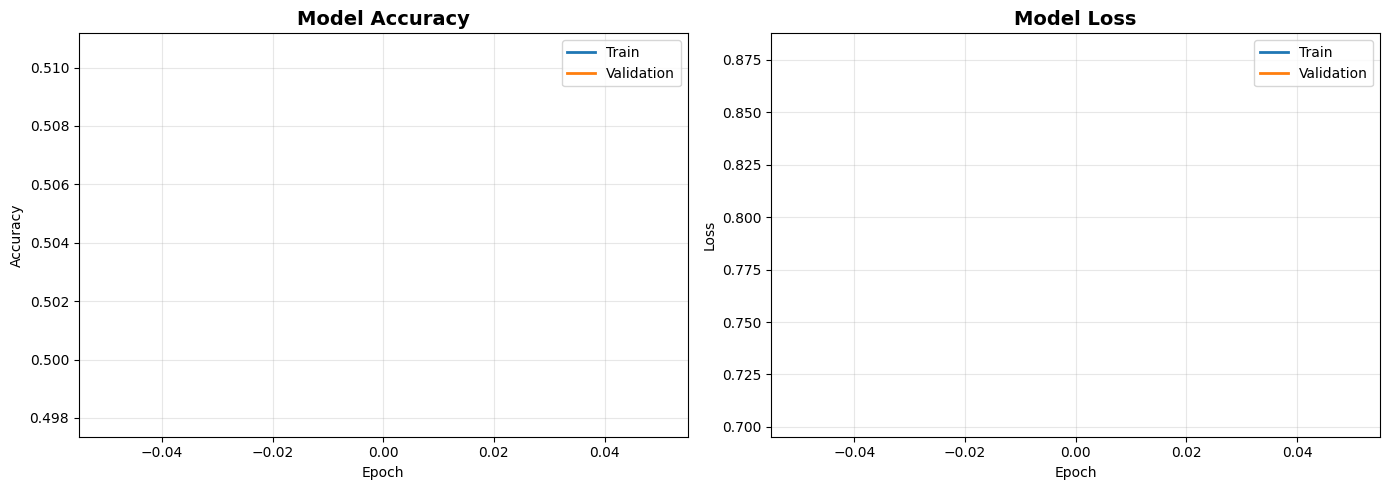

Final Train Accuracy: 51.05%
Final Val Accuracy:   49.80%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Val Accuracy:   {history.history['val_accuracy'][-1]*100:.2f}%")

In [12]:
# Baseline CNN-ViT evaluation
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(y_pred_prob, axis=1)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_pred_prob[:, 1])
baseline_kappa = cohen_kappa_score(y_test, y_pred_baseline)

cm_base = confusion_matrix(y_test, y_pred_baseline)
tn, fp, fn, tp = cm_base.ravel()
baseline_spec = tn / (tn + fp)

print("=" * 60)
print("BASELINE HYBRID CNN-ViT - TEST RESULTS")
print("=" * 60)
print(f"Accuracy   : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Precision  : {baseline_prec:.4f}")
print(f"Recall     : {baseline_rec:.4f}")
print(f"Specificity: {baseline_spec:.4f}")
print(f"F1 Score   : {baseline_f1:.4f}")
print(f"AUC        : {baseline_auc:.4f}")
print(f"Kappa      : {baseline_kappa:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline,
                            target_names=['Healthy', 'Unhealthy'], digits=4))

BASELINE HYBRID CNN-ViT - TEST RESULTS
Accuracy   : 0.4841 (48.41%)
Precision  : 0.4868
Recall     : 0.5866
Specificity: 0.3817
F1 Score   : 0.5321
AUC        : 0.4888
Kappa      : -0.0317

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.4801    0.3817    0.4253      1860
   Unhealthy     0.4868    0.5866    0.5321      1860

    accuracy                         0.4841      3720
   macro avg     0.4834    0.4841    0.4787      3720
weighted avg     0.4834    0.4841    0.4787      3720



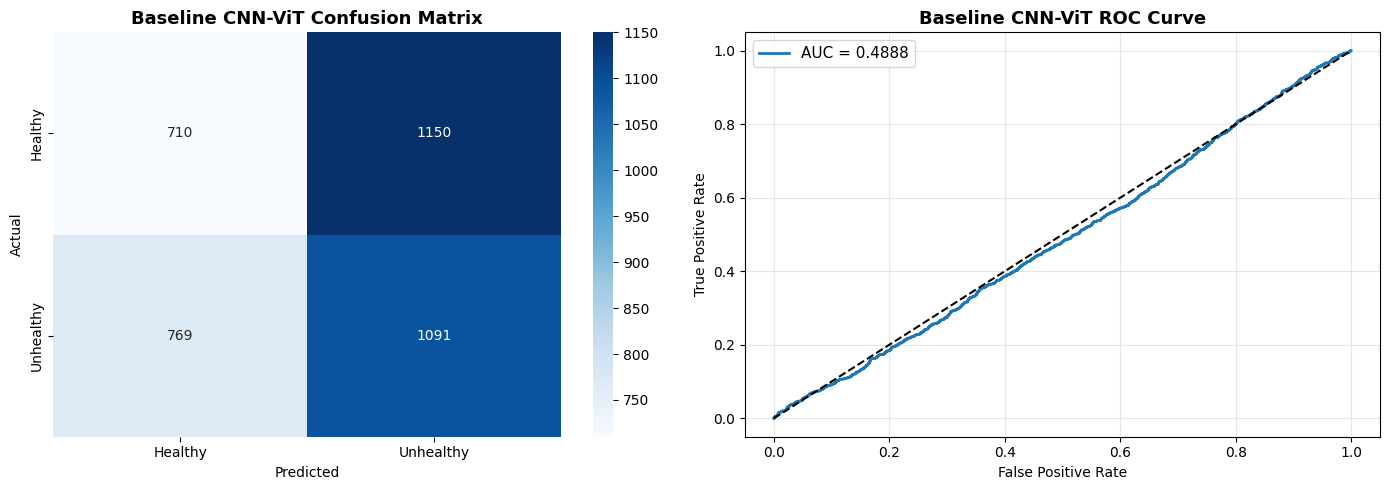

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Unhealthy'], ax=axes[0])
axes[0].set_title('Baseline CNN-ViT Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_pred_prob[:, 1])
roc_auc_b = auc(fpr_b, tpr_b)
axes[1].plot(fpr_b, tpr_b, linewidth=2, label=f'AUC = {roc_auc_b:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Baseline CNN-ViT ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/baseline_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 2: Deep Feature Extraction + ALO Feature Selection

### Approach
1. Extract **256-dimensional deep features** from the trained CNN-ViT (pooling layer output)
2. Apply **Ant Lion Optimization (ALO)** to select the most discriminative feature dimensions
3. Train **SVM, KNN, MLP** classifiers on ALO-selected deep features
4. ALO uses **3-fold stratified CV** with KNN on **training data only** (no data leakage)

In [15]:
# Create feature extractor from the trained model
feature_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer('deep_features').output,
    name='Feature_Extractor'
)

# Extract deep features
train_deep = feature_extractor.predict(X_train, verbose=0)
test_deep = feature_extractor.predict(X_test, verbose=0)

print(f"Train deep features: {train_deep.shape}")
print(f"Test deep features : {test_deep.shape}")

# Scale deep features
deep_scaler = StandardScaler()
train_deep_scaled = deep_scaler.fit_transform(train_deep)
test_deep_scaled = deep_scaler.transform(test_deep)

print("\nDeep features extracted and scaled.")

Train deep features: (14879, 256)
Test deep features : (3720, 256)

Deep features extracted and scaled.


In [16]:
# =========================================================
# ANT LION OPTIMIZATION (ALO) - Feature Selection
# =========================================================

def initialization(n, dim, ub, lb):
    return np.random.rand(n, dim) * (ub - lb) + lb

def roulette_wheel_selection(weights):
    accumulation = np.cumsum(weights)
    p = np.random.rand() * accumulation[-1]
    return np.where(accumulation >= p)[0][0]

def random_walk(t, max_iter, lb, ub, dim):
    I = 1
    if t > max_iter * 0.95: I = 1e6
    elif t > max_iter * 0.9: I = 1e5
    elif t > max_iter * 0.75: I = 1e4
    elif t > max_iter * 0.5: I = 1e3
    elif t > max_iter * 0.1: I = 1e2

    lb_adj = lb / I
    ub_adj = ub / I

    Xrw = np.cumsum(2 * (np.random.rand(max_iter, dim) > 0.5) - 1, axis=0)
    a = Xrw.min(axis=0)
    b = Xrw.max(axis=0)
    return ((Xrw - a) * (ub_adj - lb_adj)) / (b - a + 1e-10) + lb_adj

def feature_selection_fobj(pos, X_data, y_data):
    mask = pos > 0.5
    if np.sum(mask) == 0:
        return 1.0

    X_sel = X_data[:, mask]
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    accs = []
    for tr, te in skf.split(X_sel, y_data):
        clf = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski')
        clf.fit(X_sel[tr], y_data[tr])
        accs.append(accuracy_score(y_data[te], clf.predict(X_sel[te])))

    alpha = 0.99
    return alpha * (1 - np.mean(accs)) + (1 - alpha) * (np.sum(mask) / len(mask))

def ALO(SearchAgents_no, Max_iter, lb, ub, dim, X_data, y_data):
    Antlions = initialization(SearchAgents_no, dim, ub, lb)
    Antlions_fit = np.array([feature_selection_fobj(al, X_data, y_data) for al in Antlions])

    elite_idx = np.argmin(Antlions_fit)
    Elite = Antlions[elite_idx].copy()
    Elite_fit = Antlions_fit[elite_idx]

    Ants = initialization(SearchAgents_no, dim, ub, lb)
    curve = np.zeros(Max_iter)

    for t in range(Max_iter):
        ants_fit = np.zeros(SearchAgents_no)

        for i in range(SearchAgents_no):
            idx = roulette_wheel_selection(1 / (Antlions_fit + 1e-10))
            RA = random_walk(t, Max_iter, lb, ub, dim)[t] + Antlions[idx]
            RE = random_walk(t, Max_iter, lb, ub, dim)[t] + Elite
            Ants[i] = np.clip((RA + RE) / 2, lb, ub)
            ants_fit[i] = feature_selection_fobj(Ants[i], X_data, y_data)

        merged = np.vstack((Antlions, Ants))
        merged_fit = np.hstack((Antlions_fit, ants_fit))
        order = np.argsort(merged_fit)
        Antlions = merged[order[:SearchAgents_no]]
        Antlions_fit = merged_fit[order[:SearchAgents_no]]

        if Antlions_fit[0] < Elite_fit:
            Elite_fit = Antlions_fit[0]
            Elite = Antlions[0].copy()

        curve[t] = Elite_fit
        print(f"Iter {t+1}/{Max_iter} | Best Fitness = {Elite_fit:.6f} | CV Acc = {1-Elite_fit:.4f}")

    return Elite_fit, Elite, curve


# Run ALO on deep features (training data only)
print("Running ALO Feature Selection on Deep Features...")
print(f"Feature dimension: {train_deep_scaled.shape[1]}\n")

np.random.seed(42)

best_score, best_pos, alo_curve = ALO(
    SearchAgents_no=20,
    Max_iter=25,
    lb=0, ub=1,
    dim=train_deep_scaled.shape[1],
    X_data=train_deep_scaled,
    y_data=y_train
)

best_mask = best_pos > 0.5

print(f"\nALO Completed!")
print(f"Selected Features: {np.sum(best_mask)} / {len(best_mask)}")
print(f"Best CV Accuracy : {1 - best_score:.4f}")
print(f"Feature Indices  : {np.where(best_mask)[0]}")

Running ALO Feature Selection on Deep Features...
Feature dimension: 256

Iter 1/25 | Best Fitness = 0.426792 | CV Acc = 0.5732
Iter 2/25 | Best Fitness = 0.426792 | CV Acc = 0.5732
Iter 3/25 | Best Fitness = 0.426792 | CV Acc = 0.5732
Iter 4/25 | Best Fitness = 0.426792 | CV Acc = 0.5732
Iter 5/25 | Best Fitness = 0.426792 | CV Acc = 0.5732
Iter 6/25 | Best Fitness = 0.425938 | CV Acc = 0.5741
Iter 7/25 | Best Fitness = 0.425739 | CV Acc = 0.5743
Iter 8/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 9/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 10/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 11/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 12/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 13/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 14/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 15/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 16/25 | Best Fitness = 0.425473 | CV Acc = 0.5745
Iter 17/25 | Best Fitness = 0.425473 | CV Acc = 0.5745


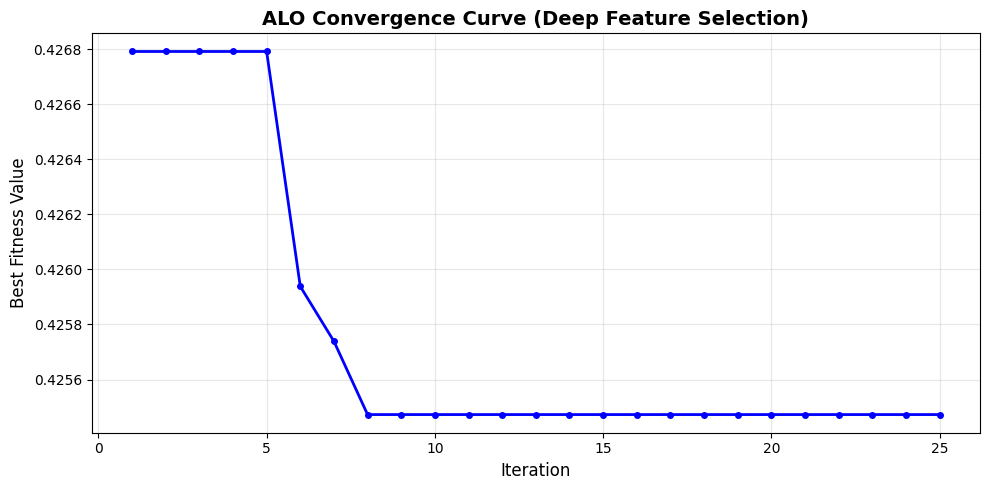

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(alo_curve)+1), alo_curve, 'b-o', linewidth=2, markersize=4)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Best Fitness Value", fontsize=12)
plt.title("ALO Convergence Curve (Deep Feature Selection)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/alo_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 3: Classifier Evaluation on ALO-Selected Deep Features

Training SVM, KNN, and MLP on the ALO-selected feature subset.
Each classifier is evaluated with full metrics, confusion matrix, and ROC curve.

Train shape after ALO: (14879, 127)
Test shape after ALO : (3720, 127)

  SVM Performance (ALO-Selected Deep Features)
Accuracy   : 0.6062 (60.62%)
Precision  : 0.6591
Recall     : 0.4398
Specificity: 0.7726
F1 Score   : 0.5276
AUC        : 0.6482
Kappa      : 0.2124

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.5797    0.7726    0.6624      1860
   Unhealthy     0.6591    0.4398    0.5276      1860

    accuracy                         0.6062      3720
   macro avg     0.6194    0.6062    0.5950      3720
weighted avg     0.6194    0.6062    0.5950      3720



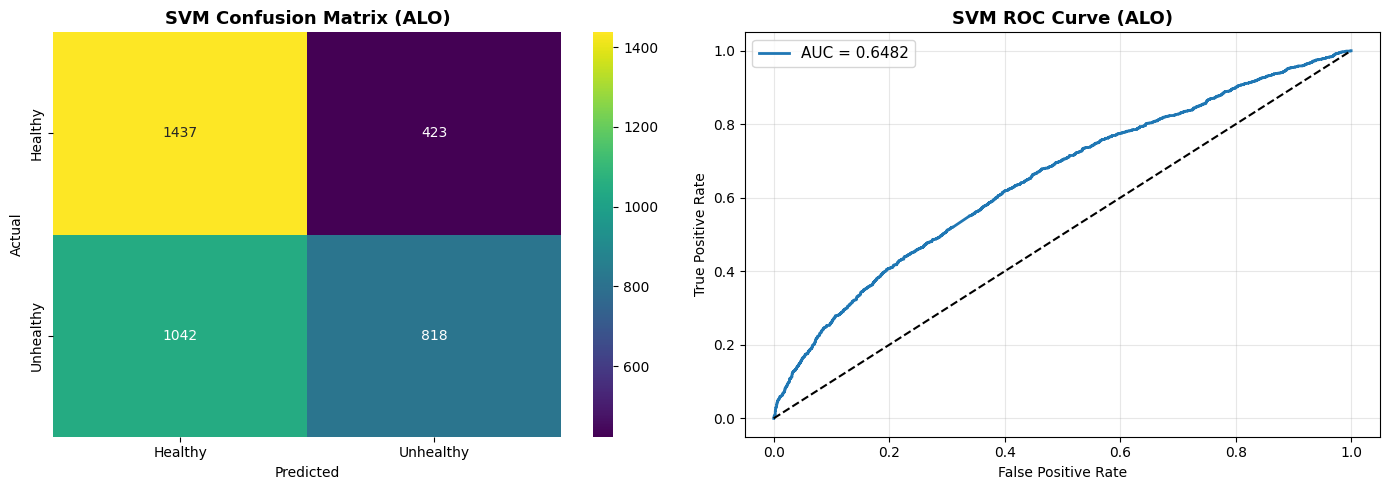


  KNN Performance (ALO-Selected Deep Features)
Accuracy   : 0.5731 (57.31%)
Precision  : 0.5729
Recall     : 0.5747
Specificity: 0.5715
F1 Score   : 0.5738
AUC        : 0.6111
Kappa      : 0.1462

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.5734    0.5715    0.5724      1860
   Unhealthy     0.5729    0.5747    0.5738      1860

    accuracy                         0.5731      3720
   macro avg     0.5731    0.5731    0.5731      3720
weighted avg     0.5731    0.5731    0.5731      3720



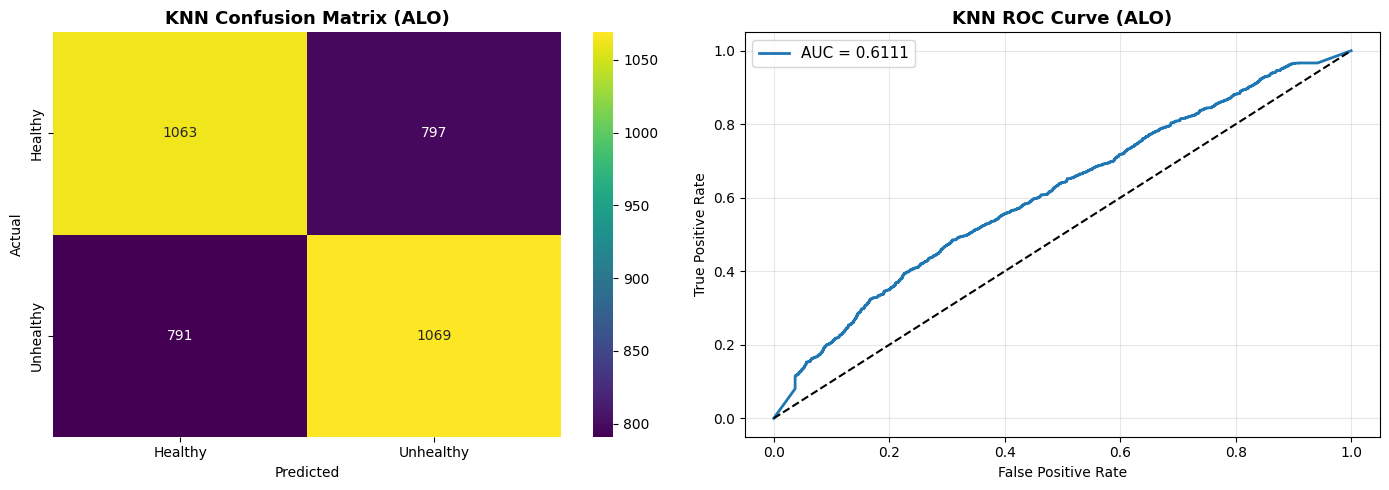


  MLP Performance (ALO-Selected Deep Features)
Accuracy   : 0.6089 (60.89%)
Precision  : 0.6112
Recall     : 0.5984
Specificity: 0.6194
F1 Score   : 0.6047
AUC        : 0.6472
Kappa      : 0.2177

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.6066    0.6194    0.6129      1860
   Unhealthy     0.6112    0.5984    0.6047      1860

    accuracy                         0.6089      3720
   macro avg     0.6089    0.6089    0.6088      3720
weighted avg     0.6089    0.6089    0.6088      3720



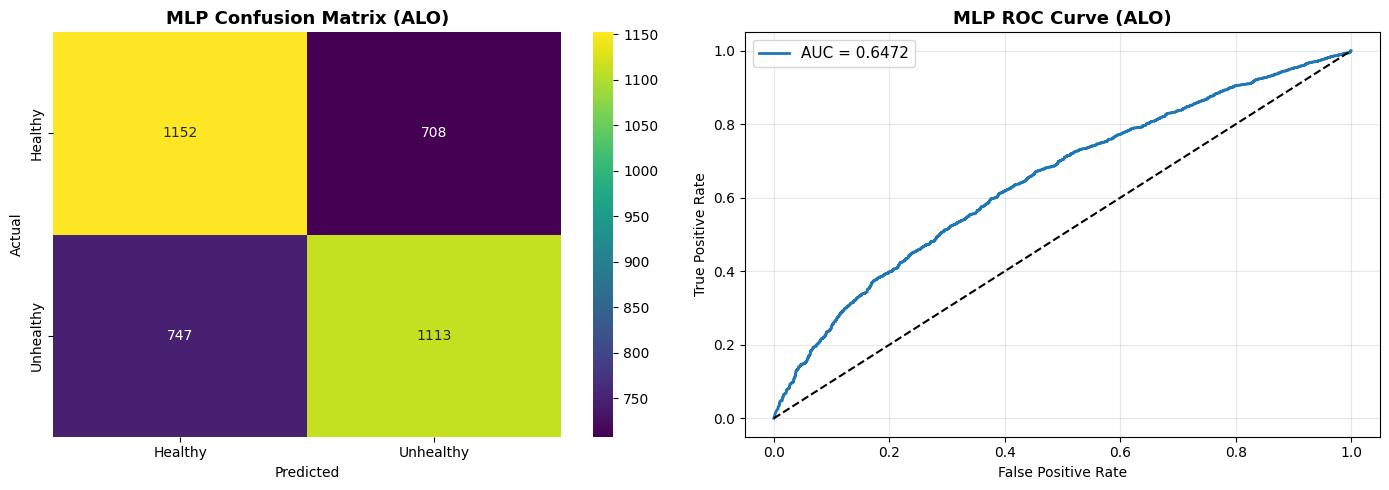


All classifiers evaluated!


In [18]:
# Apply ALO mask to deep features
X_train_alo = train_deep_scaled[:, best_mask]
X_test_alo = test_deep_scaled[:, best_mask]

print(f"Train shape after ALO: {X_train_alo.shape}")
print(f"Test shape after ALO : {X_test_alo.shape}")

# Define classifiers
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

alo_results = {}

for name, clf in classifiers.items():

    print(f"\n{'='*60}")
    print(f"  {name} Performance (ALO-Selected Deep Features)")
    print(f"{'='*60}")

    clf.fit(X_train_alo, y_train)
    preds = clf.predict(X_test_alo)
    probs = clf.predict_proba(X_test_alo)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    spec_f1 = f1_score(y_test, preds)
    auc_val = roc_auc_score(y_test, probs[:, 1])
    kappa = cohen_kappa_score(y_test, preds)

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    alo_results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'specificity': spec, 'f1': spec_f1, 'auc': auc_val,
        'kappa': kappa, 'cm': cm, 'probs': probs, 'preds': preds
    }

    print(f"Accuracy   : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision  : {prec:.4f}")
    print(f"Recall     : {rec:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"F1 Score   : {spec_f1:.4f}")
    print(f"AUC        : {auc_val:.4f}")
    print(f"Kappa      : {kappa:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, preds,
                                target_names=['Healthy', 'Unhealthy'], digits=4))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=['Healthy', 'Unhealthy'],
                yticklabels=['Healthy', 'Unhealthy'], ax=axes[0])
    axes[0].set_title(f'{name} Confusion Matrix (ALO)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_test, probs[:, 1])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f'{name} ROC Curve (ALO)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'artifacts/{name.lower()}_alo_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nAll classifiers evaluated!")


  FINAL COMPARISON: BASELINE vs ALO-IMPROVED
                    Model Accuracy Precision Recall Specificity F1-Score    AUC   Kappa
Hybrid CNN-ViT (Baseline)   48.41%    48.68% 58.66%      38.17%   53.21% 48.88% -0.0317
                ALO + SVM   60.62%    65.91% 43.98%      77.26%   52.76% 64.82%  0.2124
                ALO + KNN   57.31%    57.29% 57.47%      57.15%   57.38% 61.11%  0.1462
                ALO + MLP   60.89%    61.12% 59.84%      61.94%   60.47% 64.72%  0.2177

Best Model: ALO + MLP (Accuracy: 60.89%)


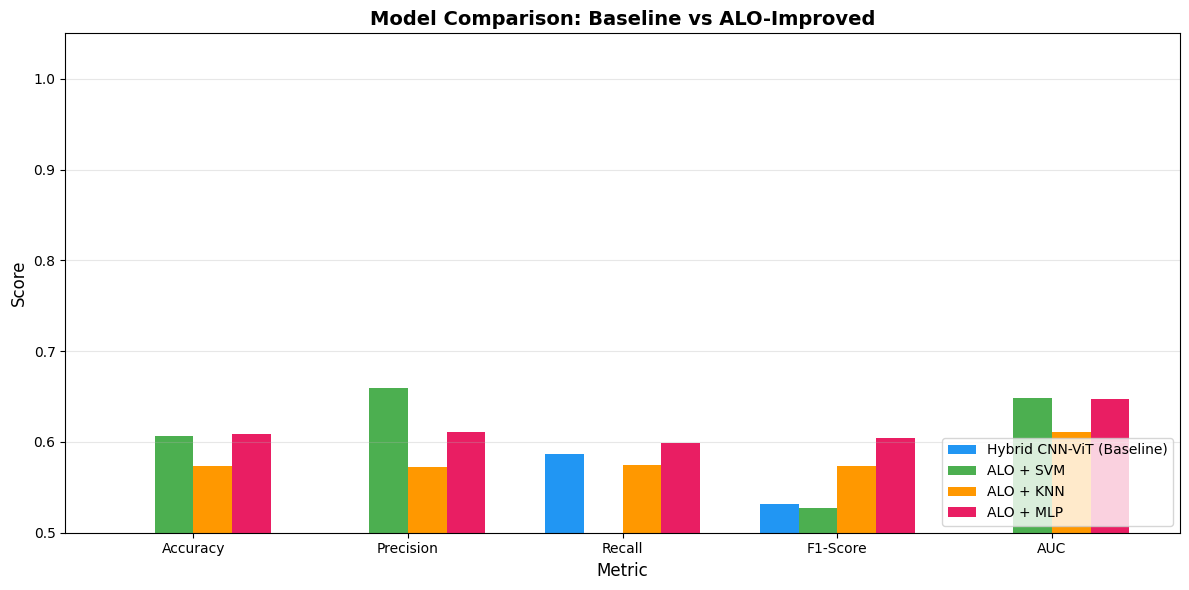

In [19]:
# =========================================================
# COMPARISON: Baseline CNN-ViT vs ALO + Classifiers
# =========================================================

comparison = {
    'Model': ['Hybrid CNN-ViT (Baseline)'],
    'Accuracy': [baseline_acc],
    'Precision': [baseline_prec],
    'Recall': [baseline_rec],
    'Specificity': [baseline_spec],
    'F1-Score': [baseline_f1],
    'AUC': [baseline_auc],
    'Kappa': [baseline_kappa]
}

for name, r in alo_results.items():
    comparison['Model'].append(f'ALO + {name}')
    comparison['Accuracy'].append(r['accuracy'])
    comparison['Precision'].append(r['precision'])
    comparison['Recall'].append(r['recall'])
    comparison['Specificity'].append(r['specificity'])
    comparison['F1-Score'].append(r['f1'])
    comparison['AUC'].append(r['auc'])
    comparison['Kappa'].append(r['kappa'])

comp_df = pd.DataFrame(comparison)

print("\n" + "="*90)
print("  FINAL COMPARISON: BASELINE vs ALO-IMPROVED")
print("="*90)

# Display with formatting
display_df = comp_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%")
display_df['Kappa'] = display_df['Kappa'].apply(lambda x: f"{float(x):.4f}")

print(display_df.to_string(index=False))
print("="*90)

# Highlight best model
best_idx = comp_df['Accuracy'].idxmax()
print(f"\nBest Model: {comp_df.loc[best_idx, 'Model']} "
      f"(Accuracy: {comp_df.loc[best_idx, 'Accuracy']*100:.2f}%)")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics_to_plot))
width = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, model_name in enumerate(comp_df['Model']):
    values = [comp_df.loc[i, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model_name, color=colors[i % len(colors)])

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Baseline vs ALO-Improved', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Save all artifacts
np.save('artifacts/alo_convergence_curve.npy', alo_curve)
np.save('artifacts/alo_best_mask.npy', best_mask)
np.save('artifacts/alo_best_position.npy', best_pos)
np.save('artifacts/training_history.npy', history.history)

# Save comparison
comp_df.to_csv('artifacts/comparison_summary.csv', index=False)

# Save predictions for each classifier
for name, r in alo_results.items():
    pred_df = pd.DataFrame({
        'True_Label': y_test,
        'Predicted_Label': r['preds'],
        'Prob_Healthy': r['probs'][:, 0],
        'Prob_Unhealthy': r['probs'][:, 1]
    })
    pred_df.to_csv(f'artifacts/{name.lower()}_alo_predictions.csv', index=False)

# Save baseline predictions
baseline_pred_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred_baseline,
    'Prob_Healthy': y_pred_prob[:, 0],
    'Prob_Unhealthy': y_pred_prob[:, 1]
})
baseline_pred_df.to_csv('artifacts/baseline_predictions.csv', index=False)

# Save model
model.save('artifacts/hybrid_cnn_vit_alo_final.h5')

print("All artifacts saved to artifacts/ directory!")
print(f"\nSummary:")
print(f"  - Selected features: {np.sum(best_mask)} / {len(best_mask)}")
print(f"  - Baseline accuracy: {baseline_acc*100:.2f}%")
best_alo_name = max(alo_results, key=lambda k: alo_results[k]['accuracy'])
print(f"  - Best ALO model: {best_alo_name} ({alo_results[best_alo_name]['accuracy']*100:.2f}%)")
print(f"  - Improvement: {(alo_results[best_alo_name]['accuracy'] - baseline_acc)*100:+.2f}%")

All artifacts saved to artifacts/ directory!

Summary:
  - Selected features: 127 / 256
  - Baseline accuracy: 48.41%
  - Best ALO model: MLP (60.89%)
  - Improvement: +12.47%
